# RAPID-MFA-5: A library of survival curves

## Descriptions
This notebook offers a selection of survival curves commonly used in dynamic MFA models with some notes and visualizations. 

The corresponding outflow-generation curves and the relationships between the two are also described below.

- The _survival curve_ answers the question "how long does an inflow cohort last in the stocks?"

- The _outflow generation curve_ answers the question "when does an inflow cohort become an outflow?"

Only one curve (either the _survival curve_ or the _outflow generation curve_ is needed as an input to a dynamic MFA model.

### The mathematical relations between the survival and outflow generation curves
The _outflow generation curve_ is the difference in the _survival curve_ between consecutive time intervals, in absolute (positive) values:

$$ 
\begin{align}
\textcolor{#FFa500}{\text{outflow\_generation\_curve}(t)} &= \left( \textcolor{#0000FF}{\text{survival\_curve}(t-1)} - \textcolor{#0000FF}{\text{survival\_curve}(t)} \right) \\
&= | \Delta \textcolor{#0000FF}{\text{survival\_curve}(t)} |
\end{align}
$$

$$
\textcolor{#0000FF}{\text{survival\_curve}(t)} = 1 - \sum_{\tau=t_0}^{t} \textcolor{#FFa500}{\text{outflow\_generation\_curve}(\tau)}
$$

In statistics / probability theory, the _outflow generation curve_ is the _probability density function_ (_probability mass function_ in the discrete case). The _survival curve_ is also called the _complementary cumulative distribution function_, the _reliability function_, or the _tail distribution_.

### Notes
1. The _outflow generation curve_ of this model is derived from the _survival curve_, not from a SciPy function, to ensure that the resulting model outputs are identical to those calculated with the model using the _survival curve_. 

    The SciPy function creates different results because of its different approach to sampling the underlying probabilty function. See the last code block for a comparison and further explanation.

2. The code blocks of each curve differ only in two sections:
    - \# mock values for the function's parameters
    - \# generate the survival curve

    The codes to derive the outflow generation curve and visualize the curves are identical every time.

### The exogenous input variables used in this example
__Inflows:__ mock values. Used in this notebook only to calculate the __ages__ range (from age zero to the maximum age to be modeled)

__Survival curves:__ mock values. The mock values of the parameters were chosen to model ~50% of the cohort still remaining after 30 timeframes. 

### Relations with other RAPID-MFA notebooks

Most RAPID MFA models use survival curves rather than outflow generation curves, unless explicitly stated otherwise.

- `RAPID-MFA-1: The flow driven model`: The _input_ __inflows__ data and the __normal distribution survival curve parameters__ are identical to those in this notebook. Here, the __inflows__ data are only used to calculate the length of the survival curve with the parameter _ages_.
- `RAPID-MFA-3: The flow driven model with an outflow generation curve` and `RAPID-MFA-4: The stock driven model with an outflow generation curve`: same code to derive the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.

### Useful references
- Each of [Wikipedia's articles on statistical distributions](https://en.wikipedia.org/wiki/List_of_probability_distributions) has a useful info box with lots of explanations of the distribution's parameters and their links to the distribution's mean, median, etc. 
- The [scipy.stats API reference](https://docs.scipy.org/doc/scipy/reference/stats.html) for how to use scipy.stats.sf, the meaning of the input parameters of each distribution, and for more statistical distributions to model survival curves.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Load libraries

In [22]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

## 2. Define example input data

The inflows data are not used for MFA modeling in this notebook, only for determining the _ages_ - the length of the survival curves - to keep consistency with the other model codes in RAPID-MFA.

In [23]:
# %% Define example input data
# timeframes
input_data = pd.Series([1300, 1400, 1200, 1000, 700, 2000, 2200, 2300, 2800, 3000, 
                        1400, 1300, 2000, 2200, 3000, 1500, 3000, 3300, 2800, 2900, 
                        1500, 2700, 3000, 3200, 3300, 3400, 3600, 3300, 3800, 3900, 
                        3300, 4000, 4400, 5000, 5100, 5200, 5400, 5800, 6200, 6000, 
                        6000, 6000, 6200, 7700, 6000, 5500, 5700, 5800, 5900, 6000, 
                        6200, 6600, 6400, 6500, 7000, 6500, 6600, 6700, 7000, 7700,
                        5800, 5900, 6000, 6000, 6200, 7700, 6000, 5500, 5700, 6700], 
                        name = 'inflows',
                        index = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 
                                 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 
                                 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 
                                 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 
                                 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 
                                 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
                                 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])  # mock values

ages = range(0, len(input_data))  # the maximum age in the MFA model is equal to the length of the input data

## 3. Survival curves and outflow generation curves

The code cells of each curve differ only in two sections:
- \# mock values for the function's parameters
- \# generate the survival curve

The codes to derive the outflow generation curve and visualize the curves are identical every time.

### 3.1 Normal distribution survival curve

The Normal distribution is an example of a curve that has a loss (outflow) from the cohort already at age zero, i.e. during the year in which the inflow occured. This loss could describe for example the share of inflows that are a short-lived throughput, becoming an outflow within the same timeframe.

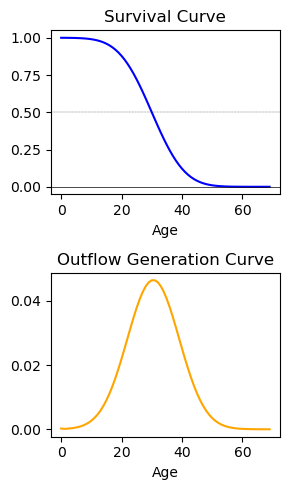

In [24]:
# %%% Normal distribution survival curve

# mock values for the function's parameters, identical to 1_flow_driven_model
mean = 30
std_dev = 30 / 3.5

# generate the survival curve
survival_curve = scipy.stats.norm.sf(ages, loc=mean, scale=std_dev)  

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

### 3.2 Weibull distribution survival curve

a short description.

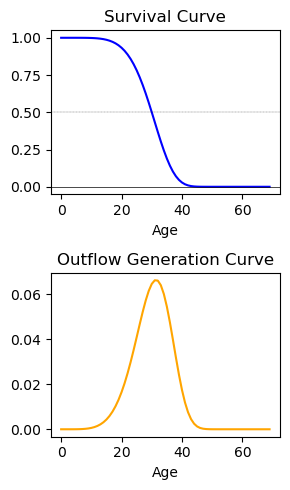

In [25]:
# %%% Weibull distribution survival curve

# mock values for the function's parameters
shape = 5.679
location = 0
scale = 32

# generate the survival curve
survival_curve = scipy.stats.weibull_min.sf(ages, c = shape, loc = location, scale = scale)

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

### 3.3 Geometric distribution survival curve / the leaching model

A fixed percent of the __remaining__ cohort in-stock goes out of stock every time-interval. 

This recreates a version of the "leaching model" $ outflow(t) = stock(t) \times depreciation\_rate $ as a cohorts-based dynamic MFA model.

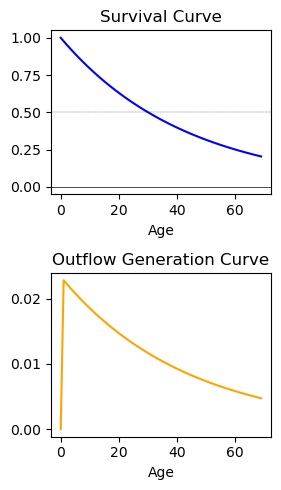

In [26]:
# %%% Geometric distribution survival curve
depreciation_rate = 0.0228

# generate the survival curve
survival_curve = scipy.stats.geom.sf(ages, depreciation_rate)

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

### 3.3 Uniform distribution survival curve

A fixed percent of the __original__ cohort inflow goes out of stock every time-interval.

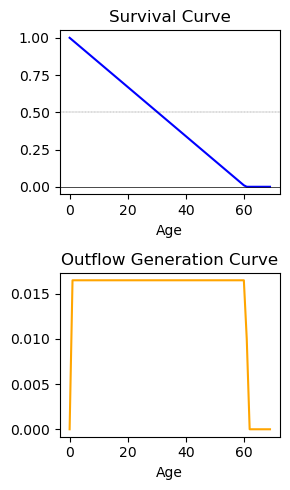

In [27]:
# %%% Uniform distribution survival curve
uniform_removal = 0.0165

# generate the survival curve
survival_curve = scipy.stats.uniform.sf(ages, loc = 0, scale = 1 / uniform_removal)

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

### 3.5 Fixed lifetime / the delay model

This recreates the "delay model" $ outflow(t) = inflow(t - lifetime) $ using the cohorts-based dynamic MFA model.
Its outflow generation curve is also called the Kronecker delta.



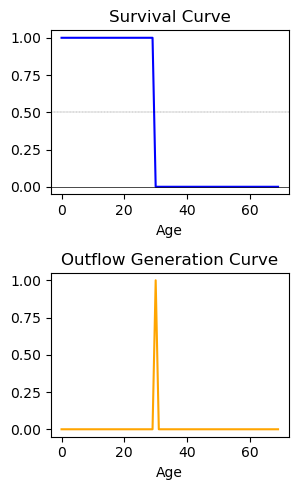

In [28]:
# %%%  Fixed lifetime / the delay model
lifetime = 30

# generate the survival curve
survival_curve = np.zeros_like(ages)
survival_curve[0:lifetime] = 1

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

### 3.6 Log-normal distribution survival curve

a short description.

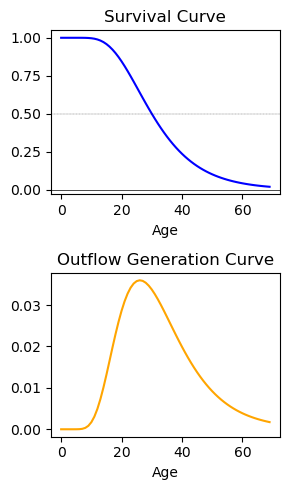

In [29]:
# %%%  Log-normal distribution survival curve

# mock values for the function's parameters
shape = 0.4
location = 0
scale = 30

# generate the survival curve
survival_curve = scipy.stats.lognorm.sf(ages, s = shape, loc = location, scale = scale)

# Define the outflow generation curve as the difference in the survival curve between time_intervals, in absolute (positive) values.
outflow_generation_curve = list(abs(np.diff(survival_curve, prepend=1)))  # prepend 1 is needed to calculate the outflow generated during cohort age 0

# Visualize the survival curve and outflow generation curve below each other
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3, 5))

ax1.plot(ages, survival_curve, label='Survival Curve', color='blue')
ax1.set_title('Survival Curve') 
ax1.set_xlabel('Age')
ax1.axhline(0,   color='black', linewidth=0.5, linestyle='solid')
ax1.axhline(0.5, color='black', linewidth=0.2, linestyle='dashed')

ax2.plot(ages, outflow_generation_curve, label='Outflow Generation Curve', color='orange')
ax2.set_title('Outflow Generation Curve')
ax2.set_xlabel('Age')

plt.tight_layout()
plt.show()

## Why it's better to avoid SciPy.pdf

Since the outflow generation curve is a distribution's probability density function (pdf), it's technically possible to get its values directly from SciPy by replaceing scipy.stats.(distribution name).sf() with scipy.stats.(distribution name).pdf().

However, SciPy's pdf method samples the distribution between two integer values, so the resulting outflow generation curve is slightly shifted and the resulting MFA system's values will not be identical to those obtained with the survival curve.

Although these look like small differences, these differences accumulate over time resulting in diverging and inconsistent results.

Furthermore, for distributions that don't have a SciPy function, like _3.5 Fixed lifetime / delay model_, there is no alternative to the differencing method.

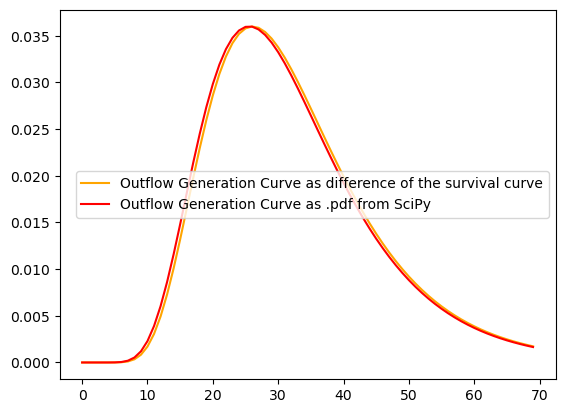

In [30]:
outflow_generation_curve_scipy = scipy.stats.lognorm.pdf(ages, s = shape, loc = location, scale = scale)

plt.plot(ages, outflow_generation_curve,
         label='Outflow Generation Curve as difference of the survival curve', color='orange')


plt.plot(ages, outflow_generation_curve_scipy, 
         label='Outflow Generation Curve as .pdf from SciPy', color='red')

plt.legend()